<a href="https://colab.research.google.com/github/melia1702/Pertemuan-ketigabelas/blob/main/TUGAS_MG_13_KLASIFIKASI_TRADISIONAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading dataset (Keras)...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape: (1000, 28, 28)
Extracting features...


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Feature shape: (1000, 1306)

===== KNN RESULTS =====
k=1, metric=euclidean, acc=0.8150, train=0.0016s, test=0.0614s
k=3, metric=euclidean, acc=0.8150, train=0.0015s, test=0.0165s
k=5, metric=euclidean, acc=0.8200, train=0.0015s, test=0.0178s
k=7, metric=euclidean, acc=0.7950, train=0.0015s, test=0.0183s
k=9, metric=euclidean, acc=0.8050, train=0.0015s, test=0.0169s
k=11, metric=euclidean, acc=0.7850, train=0.0015s, test=0.0168s
k=1, metric=manhattan, acc=0.8300, train=0.0015s, test=0.3155s
k=3, metric=manhattan, acc=0.7900, train=0.0017s, test=0.3190s
k=5, metric=manhattan, acc=0.7950, train=0.0018s, test=0.3158s
k=7, metric=manhattan, acc=0.7800, train=0.0017s, test=0.3153s
k=9, metric=manhattan, acc=0.7850, train=0.0017s, test=0.3220s
k=11, metric=manhattan, acc=0.7650, train=0.0017s, test=0.3162s

===== SVM GRID SEARCH =====
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameter: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

===== SVM EVALUATION =====
Accuracy : 

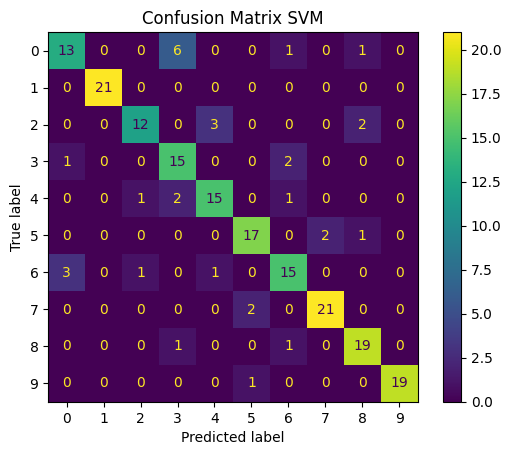


Visualizing PCA...


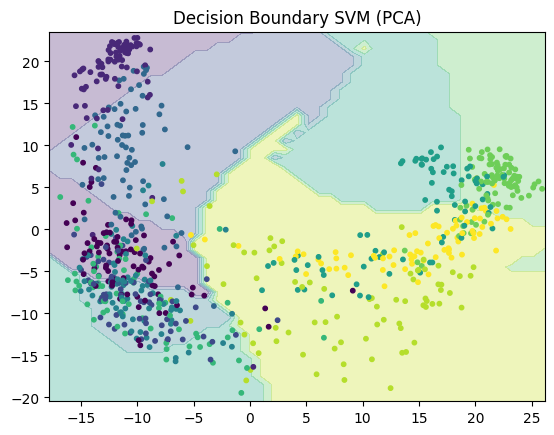


ROC Curve...


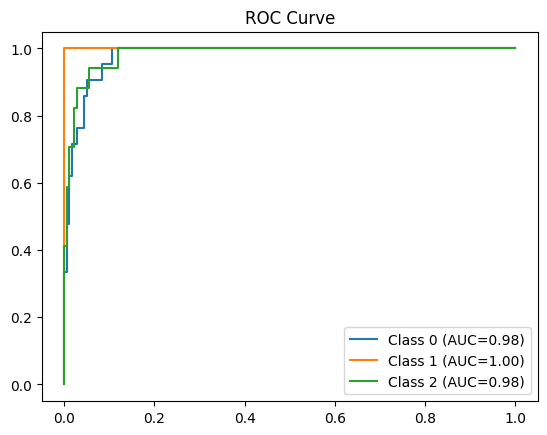


Learning Curve...


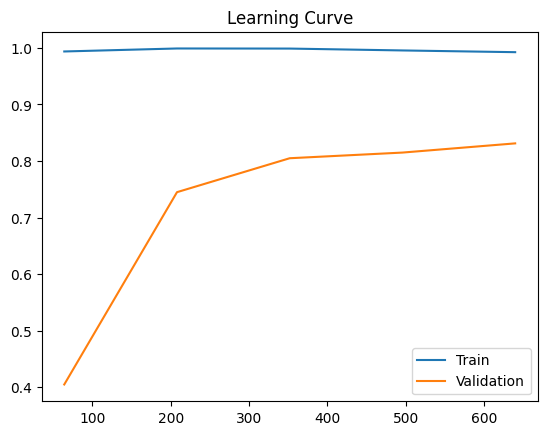


===== KESIMPULAN =====
KNN terbaik accuracy: 0.8300
SVM terbaik accuracy: 0.8350
SVM lebih baik dari KNN


In [ ]:
# ========================================
# 1. INSTALL & IMPORT LIBRARY
# ========================================
!pip install scikit-image -q

import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import fashion_mnist

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)

from skimage.feature import hog, local_binary_pattern


# ========================================
# 2. LOAD DATASET (ANTI ERROR)
# ========================================
print("Loading dataset (Keras)...")

(X_train_full, y_train_full), (X_test_full, y_test_full) = fashion_mnist.load_data()

# Gabungkan
X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)

# Ambil 1000 sampel
X = X[:1000]
y = y[:1000]

# Normalisasi
X = X / 255.0

print("Shape:", X.shape)


# ========================================
# 3. EKSTRAKSI FITUR (HOG + LBP)
# ========================================
print("Extracting features...")

def extract_features(images):
    features = []

    for img in images:
        # HOG
        hog_feat = hog(img,
                       pixels_per_cell=(4,4),
                       cells_per_block=(2,2),
                       feature_vector=True)

        # LBP
        lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
        hist, _ = np.histogram(lbp.ravel(),
                               bins=np.arange(0, 11),
                               range=(0, 10))

        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)

        features.append(np.hstack([hog_feat, hist]))

    return np.array(features)

X_feat = extract_features(X)
print("Feature shape:", X_feat.shape)


# ========================================
# 4. SPLIT DATA
# ========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ========================================
# 5. KNN (VARIASI k & METRIK)
# ========================================
print("\n===== KNN RESULTS =====")

k_values = [1,3,5,7,9,11]
metrics = ['euclidean', 'manhattan']

best_knn = None
best_acc_knn = 0

for metric in metrics:
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k, metric=metric)

        start_train = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_train

        start_test = time.time()
        y_pred = model.predict(X_test)
        test_time = time.time() - start_test

        acc = accuracy_score(y_test, y_pred)

        print(f"k={k}, metric={metric}, acc={acc:.4f}, "
              f"train={train_time:.4f}s, test={test_time:.4f}s")

        if acc > best_acc_knn:
            best_acc_knn = acc
            best_knn = model


# ========================================
# 6. SVM + GRID SEARCH
# ========================================
print("\n===== SVM GRID SEARCH =====")

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01, 0.001]
}

svm = SVC(probability=True)

cv = StratifiedKFold(n_splits=5)

grid = GridSearchCV(svm, param_grid, cv=cv, n_jobs=-1, verbose=1)

start_train = time.time()
grid.fit(X_train, y_train)
train_time_svm = time.time() - start_train

best_svm = grid.best_estimator_

start_test = time.time()
y_pred_svm = best_svm.predict(X_test)
test_time_svm = time.time() - start_test

print("Best Parameter:", grid.best_params_)


# ========================================
# 7. EVALUASI SVM
# ========================================
print("\n===== SVM EVALUATION =====")

acc = accuracy_score(y_test, y_pred_svm)
prec = precision_score(y_test, y_pred_svm, average='weighted')
rec = recall_score(y_test, y_pred_svm, average='weighted')
f1 = f1_score(y_test, y_pred_svm, average='weighted')

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)
print("Training Time :", train_time_svm)
print("Inference Time:", test_time_svm)


# ========================================
# 8. CONFUSION MATRIX
# ========================================
cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix SVM")
plt.show()


# ========================================
# 9. PCA + DECISION BOUNDARY
# ========================================
print("\nVisualizing PCA...")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

model = SVC(kernel='rbf', C=1)
model.fit(X_pca, y_train)

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 1),
                     np.arange(y_min, y_max, 1))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, s=10)
plt.title("Decision Boundary SVM (PCA)")
plt.show()


# ========================================
# 10. ROC & AUC
# ========================================
print("\nROC Curve...")

y_bin = label_binarize(y_test, classes=np.unique(y))
y_score = best_svm.predict_proba(X_test)

for i in range(3):  # tampilkan 3 kelas saja biar ringan
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.2f})')

plt.legend()
plt.title("ROC Curve")
plt.show()


# ========================================
# 11. LEARNING CURVE
# ========================================
print("\nLearning Curve...")

train_sizes, train_scores, test_scores = learning_curve(
    best_svm, X_train, y_train, cv=5)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, test_mean, label="Validation")
plt.legend()
plt.title("Learning Curve")
plt.show()


# ========================================
# 12. KESIMPULAN OTOMATIS
# ========================================
print("\n===== KESIMPULAN =====")
print(f"KNN terbaik accuracy: {best_acc_knn:.4f}")
print(f"SVM terbaik accuracy: {acc:.4f}")

if acc > best_acc_knn:
    print("SVM lebih baik dari KNN")
else:
    print("KNN lebih baik dari SVM")